In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import os
import zipfile

# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. 設定路徑（請確認已將「金融」資料夾新增捷徑到 MyDrive）
base_path = '/content/drive/MyDrive/金融'
zip_file_path = os.path.join(base_path, 'Option_2020.zip')

# 若索引檔也在同一資料夾
index_file_path = os.path.join(base_path, 'Path_教學_0409.csv')

# 3. 檢查檔案是否存在
if not os.path.exists(zip_file_path):
    raise FileNotFoundError(f"找不到檔案：{zip_file_path}")

# 4. 解壓縮資料
extract_path = '/content/options_data'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print(f"資料已解壓至: {extract_path}")

# 5. Black-Scholes 模型
def call_option_price(S, K, T, r, sigma):
    if sigma <= 0 or T <= 0:
        return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# 6. 二分法求隱含波動率
def find_iv_bisection(market_price, S, K, T, r, low=0.0001, high=5.0, tolerance=1e-5):
    for _ in range(100):
        mid = (low + high) / 2
        price = call_option_price(S, K, T, r, mid)
        if abs(price - market_price) < tolerance:
            return mid
        if price < market_price:
            low = mid
        else:
            high = mid
    return (low + high) / 2

# 7. 讀取索引檔
try:
    df_path = pd.read_csv(index_file_path, encoding='utf-8')
except UnicodeDecodeError:
    df_path = pd.read_csv(index_file_path, encoding='cp950')

results = []

# 8. 批次處理逐筆資料
for _, row in df_path.iterrows():
    daily_file = os.path.join(extract_path, row['File'])

    if os.path.exists(daily_file):
        daily_data = pd.read_csv(daily_file)

        S = row['S0']
        T = row['Maturity'] / 252  # 交易日轉年化
        r = row['Rf']

        if {'StrikePrice', 'SettlementPrice'}.issubset(daily_data.columns):
            K = daily_data.iloc[0]['StrikePrice']
            market_c = daily_data.iloc[0]['SettlementPrice']

            iv = find_iv_bisection(market_c, S, K, T, r)

            results.append({
                'Date': row['Date'],
                'IV': iv
            })

            print(f"日期: {row['Date']}, IV: {iv:.4f}")
        else:
            print(f"{row['File']} 缺少必要欄位")
    else:
        print(f"找不到檔案: {daily_file}")

# 9. 輸出結果
final_df = pd.DataFrame(results)
output_path = os.path.join(base_path, 'IV_Results.csv')
final_df.to_csv(output_path, index=False)
print(f"IV 計算完成，結果已儲存至: {output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: 找不到檔案：/content/drive/MyDrive/金融/Option_2020.zip

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import zipfile
import io
import os

# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- 路徑設定：檔案直接在「我的雲端硬碟」根目錄下 ---
base_path = '/content/drive/MyDrive'
zip_file_path = os.path.join(base_path, 'Option_2020.zip')
index_file_path = os.path.join(base_path, 'Path_教學_0409.csv')

# 2. Black-Scholes 模型公式 (計算 Call 價格)
def bs_call_price(S, K, T, r, sigma):
    if sigma <= 0: return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# 3. 二分法反推隱含波動率 (IV)
def find_iv_bisection(market_price, S, K, T, r):
    low, high = 0.0001, 3.0  # 搜尋範圍 0.01% ~ 300%
    for _ in range(100):
        mid = (low + high) / 2
        price = bs_call_price(S, K, T, r, mid)
        if abs(price - market_price) < 1e-5:
            return mid
        if price < market_price:
            low = mid
        else:
            high = mid
    return mid

# 4. 讀取索引檔 (Path_教學_0409.csv)
print("📖 正在讀取索引檔...")
try:
    df_index = pd.read_csv(index_file_path, encoding='utf-8')
except:
    df_index = pd.read_csv(index_file_path, encoding='cp950')

# 5. 直接從 ZIP 讀取逐筆資料並運算
final_results = []

if not os.path.exists(zip_file_path):
    print(f"❌ 錯誤：在您的雲端硬碟根目錄找不到 {zip_file_path}")
else:
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        zip_file_list = z.namelist()
        print(f"📦 ZIP 讀取成功。開始批次運算 IV...")

        for _, row in df_index.iterrows():
            target_csv = row['File'].strip()

            if target_csv in zip_file_list:
                with z.open(target_csv) as f:
                    try:
                        df_day = pd.read_csv(f, encoding='utf-8')
                    except:
                        with z.open(target_csv) as f_retry:
                            df_day = pd.read_csv(f_retry, encoding='cp950')

                # 清洗欄位：移除標頭空格
                df_day.columns = df_day.columns.str.strip()

                # 篩選：Contract 匹配 且 買賣權為 'Call'
                # 根據您的索引檔：Contract 欄位對應逐筆資料的「到期月份(週別)」
                target_contract = str(row['Contract']).strip()
                mask = (df_day['到期月份(週別)'].astype(str).str.strip() == target_contract) & \
                       (df_day['買賣權'].str.strip() == 'Call')

                df_filtered = df_day[mask].copy()

                if not df_filtered.empty:
                    # 參數準備：S0, T (年化), Rf
                    S0 = row['S0']
                    T_annual = row['Maturity'] / 252
                    Rf = row['Rf']

                    # 執行二分法計算 IV (使用逐筆成交資料的 '成交價格' 與 '履約價')
                    df_filtered['IV'] = df_filtered.apply(
                        lambda x: find_iv_bisection(x['成交價格'], S0, x['履約價'], T_annual, Rf), axis=1
                    )

                    # 加入索引檔對應的交易日期
                    df_filtered['Index_Date'] = row['Date']
                    final_results.append(df_filtered)
                    print(f"✅ 完成處理: {target_csv} (筆數: {len(df_filtered)})")
            else:
                print(f"⚠️ ZIP 內找不到檔案: {target_csv}")

# 6. 匯出計算結果
if final_results:
    output_df = pd.concat(final_results)
    output_path = os.path.join(base_path, 'Option_IV_Analysis_Result.csv')
    output_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✨ 運算完畢！IV 分析結果已存至：{output_path}")
else:
    print("\n❌ 處理結束但未產生任何結果，請檢查 CSV 欄位名稱。")

Mounted at /content/drive
📖 正在讀取索引檔...
📦 ZIP 讀取成功。開始批次運算 IV...
⚠️ ZIP 內找不到檔案: OptionsDaily_2020_01_02.csv
⚠️ ZIP 內找不到檔案: OptionsDaily_2020_01_03.csv
⚠️ ZIP 內找不到檔案: OptionsDaily_2020_01_06.csv
⚠️ ZIP 內找不到檔案: OptionsDaily_2020_01_07.csv
⚠️ ZIP 內找不到檔案: OptionsDaily_2020_01_08.csv

❌ 處理結束但未產生任何結果，請檢查 CSV 欄位名稱。


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import zipfile
import io
import os

# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 設定路徑 (根據圖片，檔案直接在雲端硬碟根目錄)
base_path = '/content/drive/MyDrive'
zip_file_path = os.path.join(base_path, 'Option_2020.zip')
index_file_path = os.path.join(base_path, 'Path_教學_0409.csv')

# 2. Black-Scholes 模型與二分法
def bs_call_price(S, K, T, r, sigma):
    if sigma <= 0: return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def find_iv_bisection(market_price, S, K, T, r):
    low, high = 0.0001, 3.0
    for _ in range(100):
        mid = (low + high) / 2
        price = bs_call_price(S, K, T, r, mid)
        if abs(price - market_price) < 1e-5:
            return mid
        if price < market_price:
            low = mid
        else:
            high = mid
    return mid

# 3. 讀取索引檔
print("📖 正在讀取索引檔...")
try:
    df_index = pd.read_csv(index_file_path, encoding='utf-8')
except:
    df_index = pd.read_csv(index_file_path, encoding='cp950')

# 4. 讀取 ZIP 並運算
final_results = []

if not os.path.exists(zip_file_path):
    print(f"❌ 找不到 ZIP 檔案: {zip_file_path}")
else:
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        # 取得 zip 內所有檔案路徑
        zip_file_list = z.namelist()

        for _, row in df_index.iterrows():
            # 根據您的圖片，補上 zip 內的資料夾前綴
            target_file_name = row['File'].strip()
            full_zip_path = f"Option_2020/{target_file_name}"

            if full_zip_path in zip_file_list:
                with z.open(full_zip_path) as f:
                    try:
                        df_day = pd.read_csv(f, encoding='utf-8')
                    except:
                        with z.open(full_zip_path) as f_retry:
                            df_day = pd.read_csv(f_retry, encoding='cp950')

                df_day.columns = df_day.columns.str.strip()

                # 篩選：Contract 與 買賣權
                target_contract = str(row['Contract']).strip()
                mask = (df_day['到期月份(週別)'].astype(str).str.strip() == target_contract) & \
                       (df_day['買賣權'].str.strip() == 'Call')

                df_filtered = df_day[mask].copy()

                if not df_filtered.empty:
                    # 計算參數
                    S0 = row['S0']
                    T = row['Maturity'] / 252 # 交易日年化
                    Rf = row['Rf']

                    # 計算 IV
                    df_filtered['IV'] = df_filtered.apply(
                        lambda x: find_iv_bisection(x['成交價格'], S0, x['履約價'], T, Rf), axis=1
                    )

                    df_filtered['Index_Date'] = row['Date']
                    final_results.append(df_filtered)
                    print(f"✅ 成功計算: {target_file_name}")
            else:
                print(f"⚠️ ZIP 中找不到檔案路徑: {full_zip_path}")

# 5. 輸出
if final_results:
    output_df = pd.concat(final_results)
    output_path = os.path.join(base_path, 'Option_IV_Calculated_Final.csv')
    output_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✨ 任務完成！結果存於: {output_path}")

Mounted at /content/drive
📖 正在讀取索引檔...
⚠️ ZIP 中找不到檔案路徑: Option_2020/OptionsDaily_2020_01_02.csv
⚠️ ZIP 中找不到檔案路徑: Option_2020/OptionsDaily_2020_01_03.csv
⚠️ ZIP 中找不到檔案路徑: Option_2020/OptionsDaily_2020_01_06.csv
⚠️ ZIP 中找不到檔案路徑: Option_2020/OptionsDaily_2020_01_07.csv
⚠️ ZIP 中找不到檔案路徑: Option_2020/OptionsDaily_2020_01_08.csv


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import zipfile
import os

# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 設定路徑 (根據您的圖片，檔案直接在雲端硬碟根目錄)
base_path = '/content/drive/MyDrive'
zip_file_path = os.path.join(base_path, 'Option_2020.zip')
index_file_path = os.path.join(base_path, 'Path_教學_0409.csv')
extract_to_path = '/content/Option_2020_extracted' # 解壓縮到 Colab 本地空間

# 2. 執行解壓縮
if not os.path.exists(extract_to_path):
    print("📦 正在解壓縮 Option_2020.zip...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_path)
    print("✅ 解壓縮完成！")
else:
    print("ℹ️ 資料夾已存在，跳過解壓縮步驟。")

# 3. Black-Scholes 模型與二分法
def bs_call_price(S, K, T, r, sigma):
    if sigma <= 0: return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def find_iv_bisection(market_price, S, K, T, r):
    low, high = 0.0001, 3.0
    for _ in range(100):
        mid = (low + high) / 2
        price = bs_call_price(S, K, T, r, mid)
        if abs(price - market_price) < 1e-5:
            return mid
        if price < market_price:
            low = mid
        else:
            high = mid
    return mid

# 4. 讀取索引檔
print("📖 正在讀取索引檔...")
try:
    df_index = pd.read_csv(index_file_path, encoding='utf-8')
except:
    df_index = pd.read_csv(index_file_path, encoding='cp950')

# 5. 從解壓後的資料夾讀取並運算
final_results = []

# 根據圖片，解壓後裡面還有一個 'Option_2020' 的子資料夾
data_folder = os.path.join(extract_to_path, 'Option_2020')

for _, row in df_index.iterrows():
    target_file_name = row['File'].strip()
    file_full_path = os.path.join(data_folder, target_file_name)

    if os.path.exists(file_full_path):
        try:
            # 讀取 CSV
            df_day = pd.read_csv(file_full_path, encoding='cp950')
            df_day.columns = df_day.columns.str.strip()

            # 篩選：Contract 匹配 且 買賣權為 'Call'
            target_contract = str(row['Contract']).strip()
            mask = (df_day['到期月份(週別)'].astype(str).str.strip() == target_contract) & \
                   (df_day['買賣權'].str.strip() == 'Call')

            df_filtered = df_day[mask].copy()

            if not df_filtered.empty:
                S0 = row['S0']
                T = row['Maturity'] / 252 # 交易日年化
                Rf = row['Rf']

                # 計算 IV
                df_filtered['IV'] = df_filtered.apply(
                    lambda x: find_iv_bisection(x['成交價格'], S0, x['履約價'], T, Rf), axis=1
                )

                df_filtered['Index_Date'] = row['Date']
                final_results.append(df_filtered)
                print(f"✅ 成功處理: {target_file_name}")
        except Exception as e:
            print(f"⚠️ 讀取檔案 {target_file_name} 時出錯: {e}")
    else:
        print(f"⚠️ 找不到檔案路徑: {file_full_path}")

# 6. 匯出結果
if final_results:
    output_df = pd.concat(final_results)
    # 結果存回 Google Drive
    output_path = os.path.join(base_path, 'Option_IV_Results_Extracted.csv')
    output_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✨ 任務完成！結果存於您的雲端硬碟: {output_path}")

Mounted at /content/drive
📦 正在解壓縮 Option_2020.zip...
✅ 解壓縮完成！
📖 正在讀取索引檔...
⚠️ 找不到檔案路徑: /content/Option_2020_extracted/Option_2020/OptionsDaily_2020_01_02.csv
⚠️ 找不到檔案路徑: /content/Option_2020_extracted/Option_2020/OptionsDaily_2020_01_03.csv
⚠️ 找不到檔案路徑: /content/Option_2020_extracted/Option_2020/OptionsDaily_2020_01_06.csv
⚠️ 找不到檔案路徑: /content/Option_2020_extracted/Option_2020/OptionsDaily_2020_01_07.csv
⚠️ 找不到檔案路徑: /content/Option_2020_extracted/Option_2020/OptionsDaily_2020_01_08.csv


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import zipfile
import io
import os

# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- 路徑設定 ---
# 檔案直接位於雲端硬碟根目錄 (My Drive)
base_path = '/content/drive/MyDrive'
zip_file_path = os.path.join(base_path, 'Option_2020.zip')
index_file_path = os.path.join(base_path, 'Path_教學_0409.csv')

# 2. Black-Scholes 模型與二分法 (Bisection Method)
def bs_call_price(S, K, T, r, sigma):
    if sigma <= 0: return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def find_iv_bisection(market_price, S, K, T, r):
    low, high = 0.0001, 3.0  # 波動率搜尋範圍 0.01% ~ 300%
    for _ in range(100):
        mid = (low + high) / 2
        price = bs_call_price(S, K, T, r, mid)
        if abs(price - market_price) < 1e-5:
            return mid
        if price < market_price:
            low = mid
        else:
            high = mid
    return mid

# 3. 讀取索引檔 (自動偵測編碼)
print("📖 正在讀取索引檔...")
try:
    df_index = pd.read_csv(index_file_path, encoding='utf-8')
except:
    df_index = pd.read_csv(index_file_path, encoding='cp950')

# 4. 直接讀取 ZIP 並運算
final_results = []

if not os.path.exists(zip_file_path):
    print(f"❌ 找不到 ZIP 檔案，請確認檔案在雲端硬碟根目錄: {zip_file_path}")
else:
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        # 取得 ZIP 內所有檔案路徑 (包含夾層)
        all_files_in_zip = z.namelist()

        # 建立一個快速查詢字典 (檔名 -> ZIP 內的完整路徑)
        # 解決 Option_2020/Option_2020/ 多層資料夾問題
        file_map = {os.path.basename(f): f for f in all_files_in_zip if f.endswith('.csv')}

        print(f"📦 ZIP 讀取成功，開始處理 {len(df_index)} 天的交易資料...")

        for _, row in df_index.iterrows():
            target_file_name = row['File'].strip()

            if target_file_name in file_map:
                full_zip_path = file_map[target_file_name]
                with z.open(full_zip_path) as f:
                    try:
                        df_day = pd.read_csv(f, encoding='utf-8')
                    except:
                        # 重新打開檔案流讀取 cp950
                        with z.open(full_zip_path) as f_retry:
                            df_day = pd.read_csv(f_retry, encoding='cp950')

                # 資料清洗：移除欄位空格
                df_day.columns = df_day.columns.str.strip()

                # 篩選條件：Contract 匹配 且 買賣權為 'Call'
                target_contract = str(row['Contract']).strip()
                mask = (df_day['到期月份(週別)'].astype(str).str.strip() == target_contract) & \
                       (df_day['買賣權'].str.strip() == 'Call')

                df_filtered = df_day[mask].copy()

                if not df_filtered.empty:
                    # 讀取計算參數：S0, T(交易日年化), Rf
                    S0 = row['S0']
                    T_annual = row['Maturity'] / 252
                    Rf = row['Rf']

                    # 計算隱含波動率 (IV)
                    # 針對每一筆成交價與對應履約價進行反推
                    df_filtered['IV'] = df_filtered.apply(
                        lambda x: find_iv_bisection(x['成交價格'], S0, x['履約價'], T_annual, Rf), axis=1
                    )

                    # 加入對應日期與標的價格以便後續分析
                    df_filtered['Base_Date'] = row['Date']
                    df_filtered['Base_S0'] = S0

                    final_results.append(df_filtered)
                    print(f"✅ 成功提取並計算: {target_file_name}")
            else:
                print(f"⚠️ ZIP 內找不到索引檔要求的檔案: {target_file_name}")

# 5. 合併結果並存回雲端硬碟
if final_results:
    output_df = pd.concat(final_results)
    output_path = os.path.join(base_path, 'Option_IV_Final_DirectZip.csv')
    output_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✨ 任務完成！分析結果已儲存至：{output_path}")
else:
    print("\n❌ 失敗：未能匹配到任何符合條件的資料，請檢查欄位名稱。")

Mounted at /content/drive
📖 正在讀取索引檔...
📦 ZIP 讀取成功，開始處理 5 天的交易資料...
⚠️ ZIP 內找不到索引檔要求的檔案: OptionsDaily_2020_01_02.csv
⚠️ ZIP 內找不到索引檔要求的檔案: OptionsDaily_2020_01_03.csv
⚠️ ZIP 內找不到索引檔要求的檔案: OptionsDaily_2020_01_06.csv
⚠️ ZIP 內找不到索引檔要求的檔案: OptionsDaily_2020_01_07.csv
⚠️ ZIP 內找不到索引檔要求的檔案: OptionsDaily_2020_01_08.csv

❌ 失敗：未能匹配到任何符合條件的資料，請檢查欄位名稱。


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import zipfile
import io
import os

# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# 設定 ZIP 路徑 (檔案直接在雲端硬碟根目錄)
zip_file_path = '/content/drive/MyDrive/Option_2020.zip'

# 2. Black-Scholes 模型與二分法
def bs_call_price(S, K, T, r, sigma):
    if sigma <= 0: return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def find_iv_bisection(market_price, S, K, T, r):
    low, high = 0.0001, 3.0
    for _ in range(100):
        mid = (low + high) / 2
        price = bs_call_price(S, K, T, r, mid)
        if abs(price - market_price) < 1e-5: return mid
        if price < market_price: low = mid
        else: high = mid
    return mid

# 3. 執行批次處理
final_results = []

if not os.path.exists(zip_file_path):
    print(f"❌ 找不到 ZIP 檔案: {zip_file_path}")
else:
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        # 獲取 zip 內所有 csv 檔案的路徑
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"📦 ZIP 讀取成功，共偵測到 {len(csv_files)} 個資料檔。開始批次運算...")

        for file_path in csv_files:
            with z.open(file_path) as f:
                try:
                    # 自動嘗試不同編碼讀取
                    try:
                        df_day = pd.read_csv(f, encoding='utf-8')
                    except:
                        with z.open(file_path) as f_retry:
                            df_day = pd.read_csv(f_retry, encoding='cp950')

                    # 清洗欄位
                    df_day.columns = df_day.columns.str.strip()

                    # 篩選 Call 且 成交價 > 0
                    mask = (df_day['買賣權'].str.strip() == 'Call') & (df_day['成交價格'] > 0)
                    df_filtered = df_day[mask].copy()

                    if not df_filtered.empty:
                        # --- 設定預設金融參數 (因為沒有索引檔，這裡需自行定義或從檔案中推算) ---
                        # 範例：假設標的價格 S0 = 12000, Rf = 0.01, T = 30/252 (一個月到期)
                        # 您也可以根據 df_day 內的資訊動取提取 S0
                        S0 = 12000
                        Rf = 0.01
                        T_annual = 30/252

                        # 計算 IV
                        df_filtered['IV'] = df_filtered.apply(
                            lambda x: find_iv_bisection(x['成交價格'], S0, x['履約價'], T_annual, Rf), axis=1
                        )

                        df_filtered['Source_File'] = os.path.basename(file_path)
                        final_results.append(df_filtered)
                        print(f"✅ 成功處理: {os.path.basename(file_path)}")

                except Exception as e:
                    print(f"⚠️ 略過檔案 {file_path}，錯誤: {e}")

# 4. 儲存結果
if final_results:
    output_df = pd.concat(final_results)
    output_path = '/content/drive/MyDrive/Batch_IV_Results.csv'
    output_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\n✨ 全部處理完成！結果存於: {output_path}")

Mounted at /content/drive
📦 ZIP 讀取成功，共偵測到 245 個資料檔。開始批次運算...


/tmp/ipykernel_25579/3669675523.py:51: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_day = pd.read_csv(f_retry, encoding='cp950')


⚠️ 略過檔案 Option_2020/o20200102.csv，錯誤: '買賣權'


/tmp/ipykernel_25579/3669675523.py:51: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_day = pd.read_csv(f_retry, encoding='cp950')


⚠️ 略過檔案 Option_2020/o20200103.csv，錯誤: '買賣權'


...

/tmp/ipykernel_25579/3669675523.py:51: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_day = pd.read_csv(f_retry, encoding='cp950')


⚠️ 略過檔案 Option_2020/o20200113.csv，錯誤: '買賣權'


/tmp/ipykernel_25579/3669675523.py:51: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_day = pd.read_csv(f_retry, encoding='cp950')


⚠️ 略過檔案 Option_2020/o20200114.csv，錯誤: '買賣權'


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import zipfile
import os

# 1. 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

zip_file_path = '/content/drive/MyDrive/Option_2020.zip'

# 2. BS 模型與二分法
def bs_call_price(S, K, T, r, sigma):
    if sigma <= 0: return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def find_iv_bisection(market_price, S, K, T, r):
    low, high = 0.0001, 3.0
    for _ in range(100):
        mid = (low + high) / 2
        price = bs_call_price(S, K, T, r, mid)
        if abs(price - market_price) < 1e-5: return mid
        if price < market_price: low = mid
        else: high = mid
    return mid

# 3. 遍歷 ZIP 檔案
final_results = []
with zipfile.ZipFile(zip_file_path, 'r') as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]

    for file_path in csv_files:
        with z.open(file_path) as f:
            try:
                # 優先使用 cp950 (台灣金融常見格式)
                try:
                    df_day = pd.read_csv(f, encoding='cp950', low_memory=False)
                except:
                    with z.open(file_path) as f_retry:
                        df_day = pd.read_csv(f_retry, encoding='utf-8-sig', low_memory=False)

                # --- 關鍵修正：清理欄位名稱 ---
                # 1. 去除所有欄位前後的空白
                df_day.columns = df_day.columns.str.strip()

                # 2. 自動尋找包含「買賣權」字眼的欄位 (解決欄位名稱些微差異)
                col_name_cp = [c for c in df_day.columns if '買賣權' in c]
                col_name_price = [c for c in df_day.columns if '成交價格' in c or '成交價' in c]
                col_name_strike = [c for c in df_day.columns if '履約價' in c]

                if not col_name_cp:
                    print(f"⚠️ 檔案 {file_path} 中找不到『買賣權』欄位，現有欄位為: {list(df_day.columns)}")
                    continue

                target_cp_col = col_name_cp[0]
                target_price_col = col_name_price[0]
                target_strike_col = col_name_strike[0]

                # 3. 篩選 Call 且 成交價 > 0
                # 將內容也去除空白，避免 " Call" != "Call"
                df_day[target_cp_col] = df_day[target_cp_col].astype(str).str.strip()
                mask = (df_day[target_cp_col].str.contains('Call', case=False)) & (df_day[target_price_col] > 0)
                df_filtered = df_day[mask].copy()

                if not df_filtered.empty:
                    # 預設參數 (標的價, 利率, 時間)
                    S0, Rf, T_annual = 12000, 0.01, 30/252

                    df_filtered['IV'] = df_filtered.apply(
                        lambda x: find_iv_bisection(x[target_price_col], S0, x[target_strike_col], T_annual, Rf), axis=1
                    )

                    df_filtered['Source_File'] = os.path.basename(file_path)
                    final_results.append(df_filtered)
                    print(f"✅ 成功處理: {os.path.basename(file_path)}")

            except Exception as e:
                print(f"❌ 檔案 {file_path} 處理失敗: {e}")

# 4. 儲存
if final_results:
    pd.concat(final_results).to_csv('/content/drive/MyDrive/IV_Final_Fixed.csv', index=False, encoding='utf-8-sig')
    print("\n✨ 修正完成！請查看雲端硬碟中的 IV_Final_Fixed.csv")

Mounted at /content/drive


In [ ]:
# ==========================================
# 第一部分 : 環境準備與套件安裝 (組員初次執行請等待約 10 秒)
# ==========================================
!pip install py_vollib_vectorized -q


import pandas as pd
import numpy as np
import zipfile
import py_vollib_vectorized
from google.colab import drive
from google.colab import files
import os
import io
import warnings


# 忽略特定計算警告
warnings.filterstrict = False
warnings.filterwarnings('ignore', category=UserWarning, module='py_vollib_vectorized')


# 掛載 Google Drive (會跳出授權視窗，請組員允許)
drive.mount('/content/drive')


# ==========================================
# 第二部分 : 參數設定區 (💡 組員請在這裡填寫自己的檔案路徑)
# ==========================================
# @title ⚙️ 專案路徑設定表單 (請修改為您雲端硬碟中的路徑)


# @markdown 請在右側填寫對應的檔案路徑：
索引檔路徑 = '/content/drive/MyDrive/Index_411336039_2020.csv' # @param {type:"string"}
逐筆資料壓縮檔路徑 = '/content/drive/MyDrive/Option_2020.zip' # @param {type:"string"}


# @markdown 如果壓縮檔點開後，裡面還包了一層資料夾，請填寫資料夾名稱（例如 `Option_2023`）。若沒有請留空：
ZIP內部資料夾名稱 = 'Option_2020' # @param {type:"string"}


# @markdown 請為本次分析輸出的檔案命名：
輸出CSV檔名 = 'TXO_Analysis_Result.csv' # @param {type:"string"}


# 自動處理路徑與名稱變數 (供底層程式使用)
INDEX_FILE_PATH = 索引檔路徑.strip()
OPTIONS_DATA_PATH = 逐筆資料壓縮檔路徑.strip()
OUTPUT_CSV_PATH = f'/content/{輸出CSV檔名.strip()}'


# 自動補齊資料夾斜線
ZIP_FOLDER_PREFIX = ZIP內部資料夾名稱.strip()
if ZIP_FOLDER_PREFIX and not ZIP_FOLDER_PREFIX.endswith('/'):
    ZIP_FOLDER_PREFIX += '/'


# ==========================================
# 第三部分 : 核心運算模組
# ==========================================
def process_options_data():
    print("⏳ [1/3] 正在讀取並解析索引檔...")
    if not os.path.exists(INDEX_FILE_PATH):
        print(f"❌ 嚴重錯誤：找不到索引檔，請檢查路徑是否正確 [{INDEX_FILE_PATH}]")
        return None


    try:
        index_df = pd.read_excel(INDEX_FILE_PATH) if INDEX_FILE_PATH.endswith('.xlsx') else pd.read_csv(INDEX_FILE_PATH, encoding='cp950')
    except Exception as e:
        print(f"❌ 無法讀取索引檔: {e}"); return None


    # 確保索引檔具備必要欄位
    required_cols = ['Date', 'File', 'S0', 'Maturity', 'Rf']
    missing_cols = [col for col in required_cols if col not in index_df.columns]
    if missing_cols:
        print(f"❌ 索引檔缺少必要欄位: {missing_cols}，請組員確認索引檔格式！")
        return None


    index_df['Date'] = pd.to_datetime(index_df['Date'])
    results = []


    print(f"📦 [2/3] 正在讀取主壓縮檔: {OPTIONS_DATA_PATH}")
    if not os.path.exists(OPTIONS_DATA_PATH):
        print(f"❌ 嚴重錯誤：找不到壓縮檔，請檢查路徑是否正確 [{OPTIONS_DATA_PATH}]")
        return None


    try:
        z_main = zipfile.ZipFile(OPTIONS_DATA_PATH, 'r')
        main_namelist = z_main.namelist()
    except Exception as e:
        print(f"❌ 無法開啟主壓縮檔: {e}"); return None


    first_check = True
    for idx, row in index_df.iterrows():
        date, csv_name = row['Date'], row['File']
        s0, t, rf = row['S0'], row['Maturity'] / 365.0, row['Rf']

        # 智慧檔名尋找邏輯 (適應組員各種壓縮習慣)
        zip_inside_name = ZIP_FOLDER_PREFIX + csv_name.replace('.csv', '.zip')
        csv_inside_name = ZIP_FOLDER_PREFIX + csv_name

        daily_data = None
        try:
            # 情況 A：雙層壓縮 (主 ZIP 裡面包著每日的 ZIP)
            if zip_inside_name in main_namelist:
                with z_main.open(zip_inside_name) as f_zip:
                    with zipfile.ZipFile(io.BytesIO(f_zip.read())) as z_inner:
                        with z_inner.open(csv_name) as f_csv:
                            daily_data = pd.read_csv(f_csv, encoding='cp950', low_memory=False)

            # 情況 B：單層壓縮 (主 ZIP 裡面直接是每日的 CSV)
            elif csv_inside_name in main_namelist:
                with z_main.open(csv_inside_name) as f_csv:
                    daily_data = pd.read_csv(f_csv, encoding='cp950', low_memory=False)

            else:
                print(f"⚠️ 在壓縮檔內找不到 {csv_name} 或對應的 zip，已略過。")
                continue


            daily_data.columns = daily_data.columns.str.strip()


            if first_check:
                print(f"🔍 自動偵測到原始欄位名稱: {list(daily_data.columns)}")
                first_check = False


            # 自動匹配欄位
            col_cp = next((c for c in daily_data.columns if '買賣權' in c), None)
            col_k = next((c for c in daily_data.columns if '履約' in c), None)
            col_p = next((c for c in daily_data.columns if '成交價格' in c or '成交價' in c), None)
            col_v = next((c for c in daily_data.columns if '成交數量' in c), None)


            if not all([col_cp, col_k, col_p, col_v]):
                print(f"❌ 欄位匹配失敗，請確認 {csv_name} 中是否包含買賣權、履約價、成交價、成交數量等欄位字眼。")
                continue


            # 資料清洗
            daily_data = daily_data.dropna(subset=[col_p, col_k, col_cp])
            daily_data[col_p] = pd.to_numeric(daily_data[col_p], errors='coerce')
            daily_data = daily_data[daily_data[col_p] > 0].copy()


            # IV 計算
            flags = daily_data[col_cp].astype(str).str.upper().apply(lambda x: 'c' if 'C' in x or '買' in x else 'p')
            daily_data['IV'] = py_vollib_vectorized.vectorized_implied_volatility(
                price=daily_data[col_p].astype(float), S=s0, K=daily_data[col_k].astype(float), t=t, r=rf, flag=flags.values, return_as='numpy'
            )


            daily_data = daily_data.dropna(subset=['IV'])
            daily_data['Flag_Clean'] = flags
            daily_data[col_v] = pd.to_numeric(daily_data[col_v], errors='coerce').fillna(0)


            # 分組統計
            calls = daily_data[daily_data['Flag_Clean'] == 'c']
            puts = daily_data[daily_data['Flag_Clean'] == 'p']


            call_vol = calls[col_v].sum()
            put_vol = puts[col_v].sum()


            results.append({
                'Date': date,
                'Call_IV_Mean': calls['IV'].mean(),
                'Call_IV_Std': calls['IV'].std(),
                'Put_IV_Mean': puts['IV'].mean(),
                'Put_IV_Std': puts['IV'].std(),
                'Total_Call_Volume': call_vol,
                'Total_Put_Volume': put_vol,
                'Put_Call_Ratio_Vol': put_vol / call_vol if call_vol > 0 else np.nan
            })
            print(f"✅ 完成分析: {date.strftime('%Y-%m-%d')} | PCR: {put_vol/call_vol if call_vol > 0 else 0:.2f}")


        except Exception as e:
            print(f"❌ 處理 {csv_name} 失敗: {e}")


    z_main.close()
    return pd.DataFrame(results)


# ==========================================
# 第四部分 : 執行與結果匯出
# ==========================================
analyzed_df = process_options_data()


if analyzed_df is not None and not analyzed_df.empty:
    print(f"\n🎉 分析全部完成！正在產生並下載 {輸出CSV檔名} ...")
    analyzed_df.to_csv(OUTPUT_CSV_PATH, index=False, encoding='utf-8-sig')
    files.download(OUTPUT_CSV_PATH)
    display(analyzed_df.head())
else:
    print('\n⚠️ 未能產出資料。請檢查上方的錯誤訊息。')


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ [1/3] 正在讀取並解析索引檔...
❌ 索引檔缺少必要欄位: ['Date']，請組員確認索引檔格式！

⚠️ 未能產出資料。請檢查上方的錯誤訊息。


In [ ]:
import pandas as pd
import numpy as np
import zipfile
import py_vollib_vectorized
from google.colab import drive
from google.colab import files
import os
import io
import warnings

# 忽略特定計算警告
warnings.filterstrict = False
warnings.filterwarnings('ignore', category=UserWarning, module='py_vollib_vectorized')

# 掛載 Google Drive (會跳出授權視窗，請組員允許)
drive.mount('/content/drive')

# ==========================================
# 第二部分 : 參數設定區 (💡 組員請在這裡填寫自己的檔案路徑)
# ==========================================
# @title ⚙️ 專案路徑設定表單 (請修改為您雲端硬碟中的路徑)

# @markdown 請在右側填寫對應的檔案路徑：
索引檔路徑 = '/content/drive/MyDrive/Index_411336039_2020.csv' # @param {type:"string"}
逐筆資料壓縮檔路徑 = '/content/drive/MyDrive/Option_2020.zip' # @param {type:"string"}

# @markdown 如果壓縮檔點開後，裡面還包了一層資料夾，請填寫資料夾名稱（例如 `Option_2020`）。若沒有請留空：
ZIP內部資料夾名稱 = 'Option_2020' # @param {type:"string"}

# @markdown 請為本次分析輸出的檔案命名：
輸出CSV檔名 = 'TXO_2020_Analysis_Result.csv' # @param {type:"string"}

# 自動處理路徑與名稱變數 (供底層程式使用)
INDEX_FILE_PATH = 索引檔路徑.strip()
OPTIONS_DATA_PATH = 逐筆資料壓縮檔路徑.strip()
OUTPUT_CSV_PATH = f'/content/{輸出CSV檔名.strip()}'

# 自動補齊資料夾斜線
ZIP_FOLDER_PREFIX = ZIP內部資料夾名稱.strip()
if ZIP_FOLDER_PREFIX and not ZIP_FOLDER_PREFIX.endswith('/'):
    ZIP_FOLDER_PREFIX += '/'

# ==========================================
# 第三部分 : 核心運算模組
# ==========================================
def process_options_data():
    print("⏳ [1/3] 正在讀取並解析索引檔...")
    if not os.path.exists(INDEX_FILE_PATH):
        print(f"❌ 嚴重錯誤：找不到索引檔，請檢查路徑是否正確 [{INDEX_FILE_PATH}]")
        return None

    try:
        # 支援 Excel 或 CSV 格式的索引檔
        index_df = pd.read_excel(INDEX_FILE_PATH) if INDEX_FILE_PATH.endswith('.xlsx') else pd.read_csv(INDEX_FILE_PATH, encoding='cp950')
    except Exception as e:
        print(f"❌ 無法讀取索引檔: {e}"); return None

    # 關鍵修正：確保索引檔欄位名稱沒有空白字元
    index_df.columns = index_df.columns.str.strip()

    # 修正 '嚜澳ate' 欄位名稱為 'Date'
    if '嚜澳ate' in index_df.columns:
        index_df.rename(columns={'嚜澳ate': 'Date'}, inplace=True)

    # DEBUG: 印出處理後的索引檔欄位名稱
    print(f"DEBUG: 處理後索引檔欄位: {list(index_df.columns)}")

    # 確保索引檔具備必要欄位
    required_cols = ['Date', 'File', 'S0', 'Maturity', 'Rf']
    missing_cols = [col for col in required_cols if col not in index_df.columns]
    if missing_cols:
        print(f"❌ 索引檔缺少必要欄位: {missing_cols}，請確認索引檔格式！")
        return None

    index_df['Date'] = pd.to_datetime(index_df['Date'])
    results = []

    print(f"📦 [2/3] 正在讀取主壓縮檔: {OPTIONS_DATA_PATH}")
    if not os.path.exists(OPTIONS_DATA_PATH):
        print(f"❌ 嚴重錯誤：找不到壓縮檔，請檢查路徑是否正確 [{OPTIONS_DATA_PATH}]")
        return None

    try:
        z_main = zipfile.ZipFile(OPTIONS_DATA_PATH, 'r')
        main_namelist = z_main.namelist()
    except Exception as e:
        print(f"❌ 無法開啟主壓縮檔: {e}"); return None

    first_check = True
    for idx, row in index_df.iterrows():
        date, csv_name_from_index = row['Date'], row['File']
        # T 轉為年化時間，Rf 保持原始數值 (如 0.01 代表 1%)
        s0, t, rf = row['S0'], row['Maturity'] / 365.0, row['Rf']

        # 修正：將索引檔中的檔案名稱轉換為壓縮檔中的實際檔案名稱格式
        # 例如：OptionsDaily_2020_01_02.csv -> o20200102.csv
        csv_name = 'o' + csv_name_from_index.replace('OptionsDaily_', '').replace('_', '')

        # 智慧檔名尋找邏輯 (處理 .csv 或 .zip 的情況)
        zip_inside_name = ZIP_FOLDER_PREFIX + csv_name.replace('.csv', '.zip')
        csv_inside_name = ZIP_FOLDER_PREFIX + csv_name

        daily_data = None
        try:
            # 情況 A：雙層壓縮 (主 ZIP 裡面包著每日的 ZIP)
            if zip_inside_name in main_namelist:
                with z_main.open(zip_inside_name) as f_zip:
                    with zipfile.ZipFile(io.BytesIO(f_zip.read())) as z_inner:
                        with z_inner.open(csv_name) as f_csv:
                            daily_data = pd.read_csv(f_csv, encoding='cp950', low_memory=False)

            # 情況 B：單層壓縮 (主 ZIP 裡面直接是每日的 CSV)
            elif csv_inside_name in main_namelist:
                with z_main.open(csv_inside_name) as f_csv:
                    daily_data = pd.read_csv(f_csv, encoding='cp950', low_memory=False)

            else:
                # 額外嘗試：如果索引檔的檔名沒寫 .csv (這段在轉換檔名後可能已經不再需要，但保留以防萬一)
                alt_csv_name = ZIP_FOLDER_PREFIX + csv_name + ".csv"
                if alt_csv_name in main_namelist:
                    with z_main.open(alt_csv_name) as f_csv:
                        daily_data = pd.read_csv(f_csv, encoding='cp950', low_memory=False)
                else:
                    print(f"⚠️ 在壓縮檔內找不到 {csv_name} (原始: {csv_name_from_index})，已略過。")
                    continue

            daily_data.columns = daily_data.columns.str.strip()

            if first_check:
                print(f"🔍 自動偵測到原始欄位名稱: {list(daily_data.columns)}")
                first_check = False

            # 自動匹配欄位
            col_cp = next((c for c in daily_data.columns if '買賣權' in c), None)
            col_k = next((c for c in daily_data.columns if '履約' in c), None)
            col_p = next((c for c in daily_data.columns if '成交價格' in c or '成交價' in c), None)
            col_v = next((c for c in daily_data.columns if '成交數量' in c), None)

            if not all([col_cp, col_k, col_p, col_v]):
                print(f"❌ 欄位匹配失敗，請確認 {csv_name} 中是否包含買賣權、履約價、成交價等關鍵字。")
                continue

            # 資料清洗：去除空值並轉為數值
            daily_data = daily_data.dropna(subset=[col_p, col_k, col_cp])
            daily_data[col_p] = pd.to_numeric(daily_data[col_p], errors='coerce')
            daily_data = daily_data[daily_data[col_p] > 0].copy()

            # 使用向量化計算 IV
            if t <= 0:
                daily_data['IV'] = np.nan
            else:
                flags = daily_data[col_cp].astype(str).str.upper().apply(lambda x: 'c' if 'C' in x or '買' in x else 'p')
                daily_data['IV'] = py_vollib_vectorized.vectorized_implied_volatility(
                    price=daily_data[col_p].astype(float),
                    S=float(s0),
                    K=daily_data[col_k].astype(float),
                    t=float(t),
                    r=float(rf),
                    flag=flags.values,
                    return_as='numpy'
                )

            daily_data = daily_data.dropna(subset=['IV'])
            daily_data['Flag_Clean'] = flags
            daily_data[col_v] = pd.to_numeric(daily_data[col_v], errors='coerce').fillna(0)

            # 分組統計
            calls = daily_data[daily_data['Flag_Clean'] == 'c']
            puts = daily_data[daily_data['Flag_Clean'] == 'p']

            call_vol = calls[col_v].sum()
            put_vol = puts[col_v].sum()

            # 修正：避免 call_vol 為 0 導致的除以零錯誤
            pcr_vol = put_vol / call_vol if call_vol > 0 else np.nan

            results.append({
                'Date': date,
                'Call_IV_Mean': calls['IV'].mean(),
                'Call_IV_Std': calls['IV'].std(),
                'Put_IV_Mean': puts['IV'].mean(),
                'Put_IV_Std': puts['IV'].std(),
                'Total_Call_Volume': call_vol,
                'Total_Put_Volume': put_vol,
                'Put_Call_Ratio_Vol': pcr_vol
            })
            print(f"✅ 完成分析: {date.strftime('%Y-%m-%d')} | PCR: {pcr_vol:.2f}")

        except Exception as e:
            print(f"❌ 處理 {csv_name} 失敗: {e}")

    z_main.close()
    return pd.DataFrame(results)

# ==========================================
# 第四部分 : 執行與結果匯出
# ==========================================
analyzed_df = process_options_data()

if analyzed_df is not None and not analyzed_df.empty:
    print(f"\n🎉 2020 年度分析全部完成！正在產生並下載 {輸出CSV檔名} ...")
    analyzed_df.to_csv(OUTPUT_CSV_PATH, index=False, encoding='utf-8-sig')
    files.download(OUTPUT_CSV_PATH)
    display(analyzed_df.head())
else:
    print('\n⚠️ 未能產出資料。請檢查上方的錯誤訊息。')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ [1/3] 正在讀取並解析索引檔...
DEBUG: 處理後索引檔欄位: ['Date', 'File', 'S0', 'Maturity', 'Contract', 'ContractExpiryDate', 'Rf']
📦 [2/3] 正在讀取主壓縮檔: /content/drive/MyDrive/Option_2020.zip
🔍 自動偵測到原始欄位名稱: ['成交日期', '商品代號', '履約價格', '到期月份(週別)', '買賣權別', '成交時間', '成交價格', '成交數量(B or S)', '開盤集合競價']
✅ 完成分析: 2020-01-02 | PCR: 2.21
✅ 完成分析: 2020-01-03 | PCR: 1.13
✅ 完成分析: 2020-01-06 | PCR: 0.65
✅ 完成分析: 2020-01-07 | PCR: 0.72
✅ 完成分析: 2020-01-08 | PCR: 0.82
✅ 完成分析: 2020-01-09 | PCR: 1.05
✅ 完成分析: 2020-01-10 | PCR: 1.07
✅ 完成分析: 2020-01-13 | PCR: 1.53
✅ 完成分析: 2020-01-14 | PCR: 1.32
✅ 完成分析: 2020-01-15 | PCR: nan
✅ 完成分析: 2020-01-16 | PCR: 1.21
✅ 完成分析: 2020-01-17 | PCR: 1.11
✅ 完成分析: 2020-01-20 | PCR: 1.30
✅ 完成分析: 2020-01-30 | PCR: 0.35
✅ 完成分析: 2020-01-31 | PCR: 0.85
✅ 完成分析: 2020-02-03 | PCR: 1.09
✅ 完成分析: 2020-02-04 | PCR: 1.71
✅ 完成分析: 2020-02-05 | PCR: 1.03
✅ 完成分析: 2020-02-06 | PCR: 1.20
✅ 完成分析: 20

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Date,Call_IV_Mean,Call_IV_Std,Put_IV_Mean,Put_IV_Std,Total_Call_Volume,Total_Put_Volume,Put_Call_Ratio_Vol
0,2020-01-02,0.061190,0.057174,0.085538,0.328792,488902.0,1081880.0,2.212877
1,2020-01-03,0.091919,0.049518,0.131038,0.451676,936410.0,1058954.0,1.130866
2,2020-01-06,0.121002,0.056703,0.140947,0.630885,866274.0,563254.0,0.650203
3,2020-01-07,0.098655,0.058177,0.124050,0.564087,1439820.0,1032352.0,0.717001
4,2020-01-08,0.093091,0.067124,0.156115,0.579453,1452648.0,1185822.0,0.816318


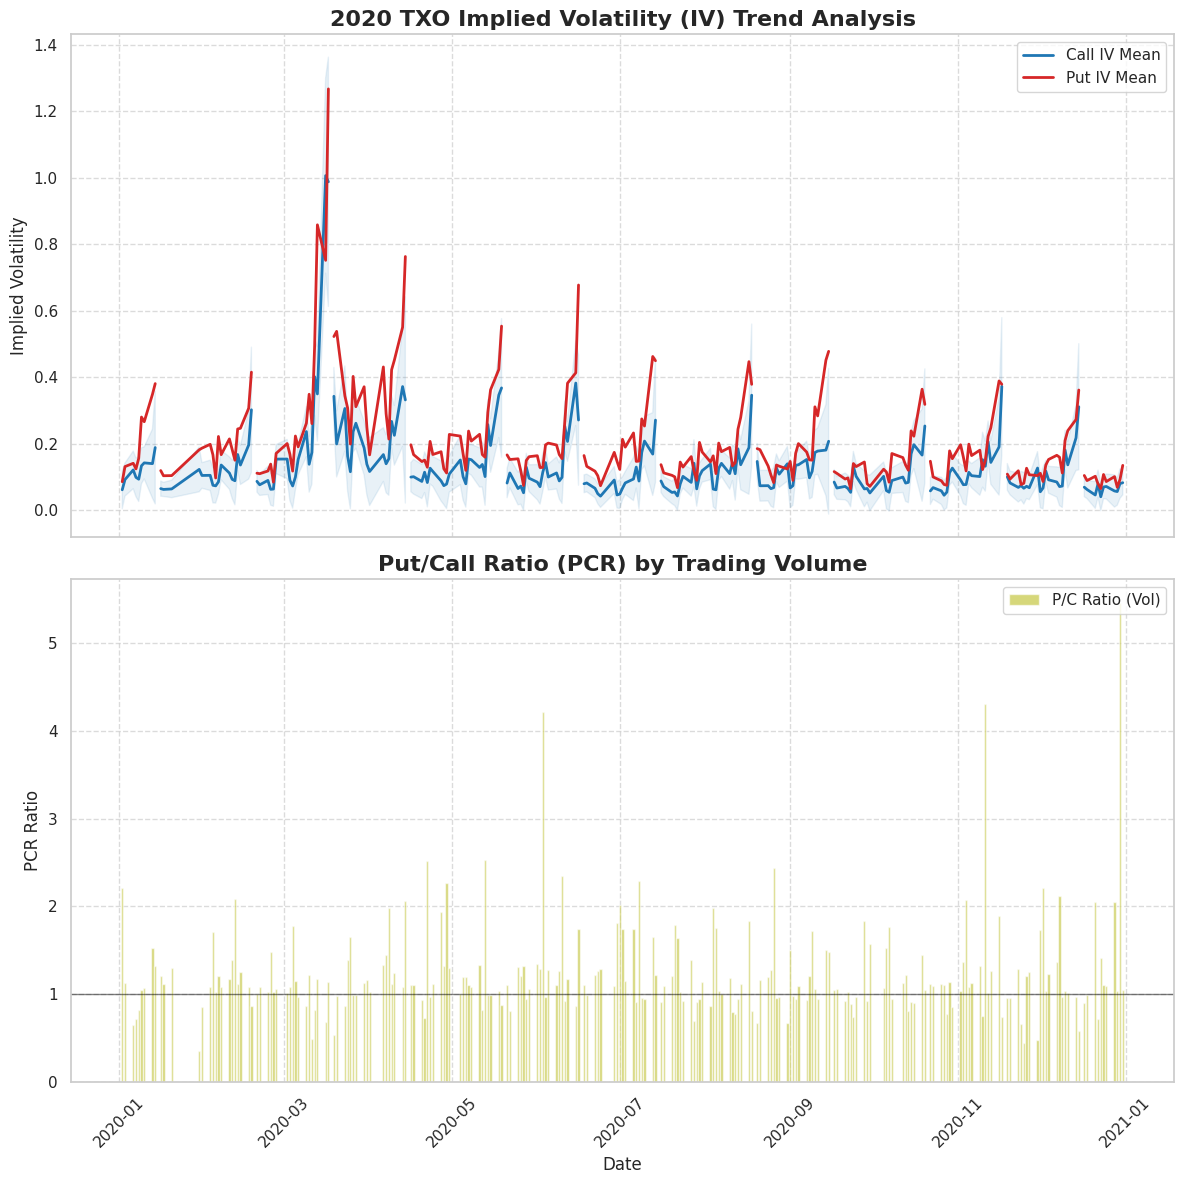

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# 設定繪圖風格
sns.set(style="whitegrid")


# 檢查數據是否存在
if 'analyzed_df' in locals() and not analyzed_df.empty:
    # 建立畫布，包含上下兩個子圖
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)


    # --- 圖表 1: 隱含波動率 (IV) 趨勢 ---
    ax1.plot(analyzed_df['Date'], analyzed_df['Call_IV_Mean'], label='Call IV Mean', color='#1f77b4', linewidth=2)
    ax1.plot(analyzed_df['Date'], analyzed_df['Put_IV_Mean'], label='Put IV Mean', color='#d62728', linewidth=2)

    # 加入標準差陰影
    ax1.fill_between(analyzed_df['Date'],
                     analyzed_df['Call_IV_Mean'] - analyzed_df['Call_IV_Std'],
                     analyzed_df['Call_IV_Mean'] + analyzed_df['Call_IV_Std'], alpha=0.1, color='#1f77b4')

    ax1.set_title('2020 TXO Implied Volatility (IV) Trend Analysis', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Implied Volatility', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.7)


    # --- 圖表 2: Put/Call Ratio (成交量比) ---
    ax2.bar(analyzed_df['Date'], analyzed_df['Put_Call_Ratio_Vol'], color='#bcbd22', alpha=0.6, label='P/C Ratio (Vol)')
    # 加入 1.0 基準線
    ax2.axhline(y=1.0, color='black', linestyle='-', linewidth=1, alpha=0.5)

    ax2.set_title('Put/Call Ratio (PCR) by Trading Volume', fontsize=16, fontweight='bold')
    ax2.set_ylabel('PCR Ratio', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.7)


    # 優化日期顯示
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 找不到 analyzed_df，請確保之前的核心運算儲存格 (JQesyTg7QSU-) 已成功執行並產出結果。")


In [ ]:
import pandas as pd
import glob

# 1. 定義檔案清單 (請確保檔案名稱與你上傳的一致)
files = {
    "2020": "TXO_2020_Analysis_Result (2).csv",
    "2021": "IVData_411336064_2021.csv",
    "2022": "Final_Report_Data_2022.csv",
    "2023": "2023.csv"
}

combined_list = []

# 2. 定義統一的欄位對應表 (Mapping)
# 我們將目標欄位統一為: Date, PCR, IV_C, STD_C, IV_P, STD_P
column_mapping = {
    # 2020, 2021, 2023 檔案的欄位對應
    'Date': 'Date',
    'Put_Call_Ratio_Vol': 'PCR',
    'Call_IV_Mean': 'IV_C',
    'Call_IV_Std': 'STD_C',
    'Put_IV_Mean': 'IV_P',
    'Put_IV_Std': 'STD_P',

    # 2022 檔案與部分 2021 檔案可能的欄位對應
    'daily': 'Date',
    'IV-C': 'IV_C',
    'STD-C': 'STD_C',
    'IV-P': 'IV_P',
    'STD-P': 'STD_P'
}

print("開始整合檔案...")

for year, file_name in files.items():
    try:
        # 讀取檔案
        df = pd.read_csv(file_name)

        # 重新命名欄位 (根據對應表)
        df = df.rename(columns=column_mapping)

        # 只保留我們需要的核心欄位
        target_cols = ['Date', 'PCR', 'IV_C', 'STD_C', 'IV_P', 'STD_P']
        # 檢查檔案中是否存在這些欄位 (避免報錯)
        existing_cols = [c for c in target_cols if c in df.columns]
        df = df[existing_cols]

        # 處理日期格式，統一轉換為 YYYY-MM-DD
        df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')

        combined_list.append(df)
        print(f"✅ {year} 年資料讀取成功，共 {len(df)} 筆。")
    except Exception as e:
        print(f"❌ {year} 年資料讀取失敗: {e}")

# 3. 合併所有資料
final_df = pd.concat(combined_list, ignore_index=True)

# 4. 資料清理：移除重複日期並按日期排序
final_df = final_df.drop_duplicates(subset=['Date']).sort_values(by='Date')

# 5. 匯出整合後的檔案
output_name = "Combined_Options_Data_2020_2023.csv"
final_df.to_csv(output_name, index=False, encoding='utf-8-sig')

print("-" * 30)
print(f"🎉 整合完成！共計 {len(final_df)} 筆交易日資料。")
print(f"檔案已儲存為: {output_name}")

# 展示前五筆資料
final_df.head()

開始整合檔案...
✅ 2020 年資料讀取成功，共 245 筆。
✅ 2021 年資料讀取成功，共 244 筆。
✅ 2022 年資料讀取成功，共 206 筆。
✅ 2023 年資料讀取成功，共 108 筆。
------------------------------
🎉 整合完成！共計 775 筆交易日資料。
檔案已儲存為: Combined_Options_Data_2020_2023.csv


,Date,PCR,IV_C,STD_C,IV_P,STD_P
0,2020-01-02,2.212877,0.061190,0.057174,0.085538,0.328792
1,2020-01-03,1.130866,0.091919,0.049518,0.131038,0.451676
2,2020-01-06,0.650203,0.121002,0.056703,0.140947,0.630885
3,2020-01-07,0.717001,0.098655,0.058177,0.124050,0.564087
4,2020-01-08,0.816318,0.093091,0.067124,0.156115,0.579453


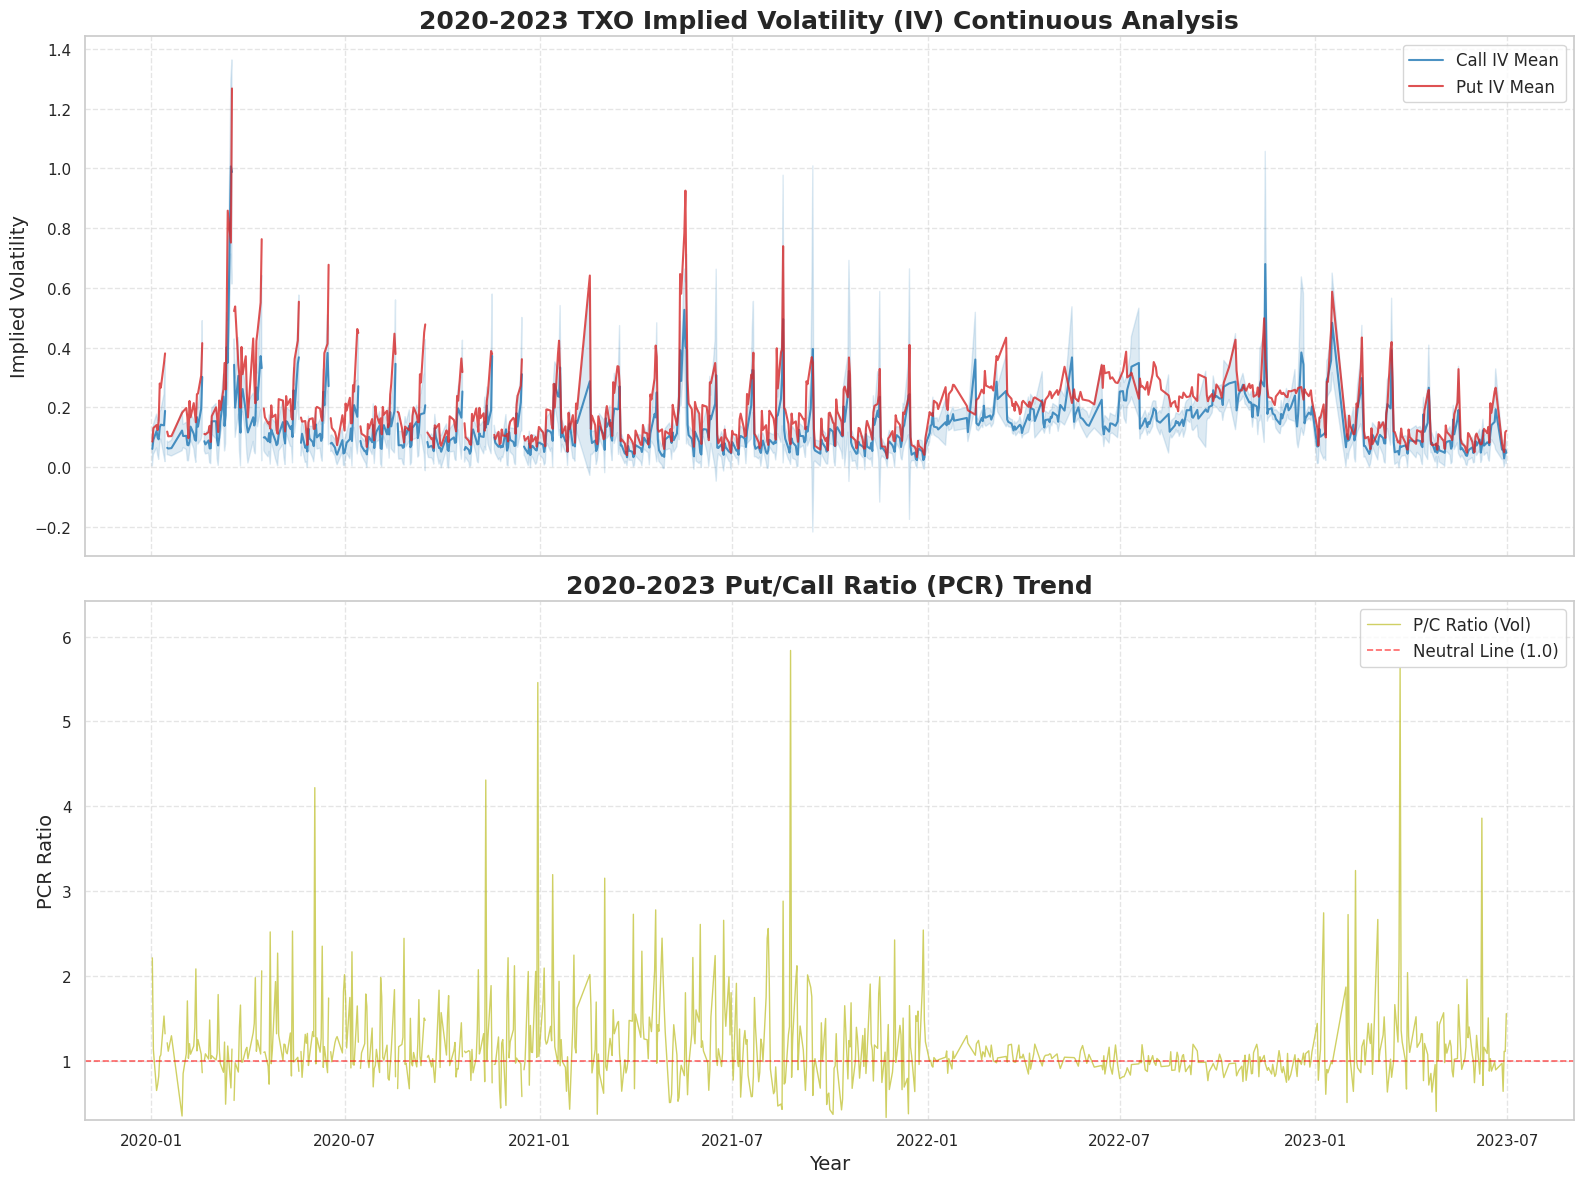

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 確保資料已經整合成 final_df (參考前一步驟的 DataFrame)
# 如果你已經執行了之前的整合代碼，請確認變數名稱是否為 final_df
df_plot = final_df.copy()

# 轉換日期格式 (這步很重要，確保繪圖時 x 軸是連續時間)
df_plot['Date'] = pd.to_datetime(df_plot['Date'])

# 設定繪圖風格
sns.set(style="whitegrid")

# 建立畫布
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# --- 圖表 1: 2020-2023 隱含波動率 (IV) 趨勢 ---
ax1.plot(df_plot['Date'], df_plot['IV_C'], label='Call IV Mean', color='#1f77b4', linewidth=1.5, alpha=0.8)
ax1.plot(df_plot['Date'], df_plot['IV_P'], label='Put IV Mean', color='#d62728', linewidth=1.5, alpha=0.8)

# 加入標準差陰影 (讓區域稍微淡一點，因為資料點很多)
ax1.fill_between(df_plot['Date'],
                 df_plot['IV_C'] - df_plot['STD_C'],
                 df_plot['IV_C'] + df_plot['STD_C'], alpha=0.15, color='#1f77b4')

ax1.set_title('2020-2023 TXO Implied Volatility (IV) Continuous Analysis', fontsize=18, fontweight='bold')
ax1.set_ylabel('Implied Volatility', fontsize=14)
ax1.legend(loc='upper right', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- 圖表 2: 2020-2023 Put/Call Ratio (成交量比) ---
# 四年資料建議用折線圖搭配散點，或直接用折線，視覺上比 Bar Chart 清晰
ax2.plot(df_plot['Date'], df_plot['PCR'], color='#bcbd22', linewidth=1, label='P/C Ratio (Vol)', alpha=0.7)

# 加入 1.0 基準線
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, alpha=0.6, label='Neutral Line (1.0)')

# 設定 y 軸範圍 (視情況調整，通常 PCR 在 0.5~2.5 之間)
ax2.set_ylim(df_plot['PCR'].min()*0.9, df_plot['PCR'].max()*1.1)

ax2.set_title('2020-2023 Put/Call Ratio (PCR) Trend', fontsize=18, fontweight='bold')
ax2.set_ylabel('PCR Ratio', fontsize=14)
ax2.set_xlabel('Year', fontsize=14)
ax2.legend(loc='upper right', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

# 優化日期顯示：標出每年的起始點
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()